# Nombre: Atzin Eduardo Cruz Briones

# Practica 5: Embeddings

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
from gensim.models import KeyedVectors

In [3]:
model = KeyedVectors.load_word2vec_format('GNvectors.bin', binary=True)

## Características del Dataset GNVectors de Google
## 1) El dataset con el que fue entrenada esta red tenía 1 billón de palabras 
## 2) El vocabulario fue de 692 mil palabras unicas. 
## 3) Cada palabras es reprensetada en 300 dimensiones (tamaño de la capa oculta)

In [4]:
def pp(obj):
    print(pd.DataFrame(obj))

In [6]:
pp(model['table'])

            0
0   -0.144531
1   -0.026489
2    0.117676
3    0.213867
4   -0.042236
..        ...
295 -0.076660
296  0.069824
297 -0.095215
298 -0.098145
299 -0.012268

[300 rows x 1 columns]


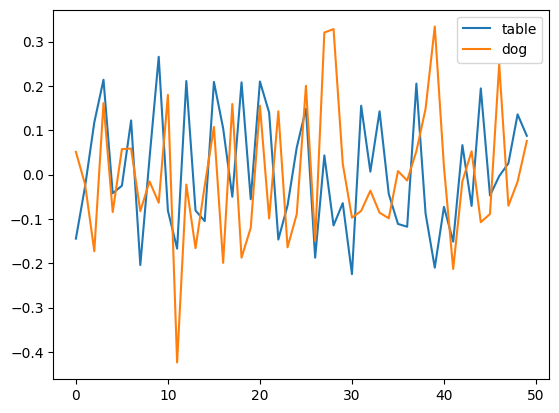

In [11]:
plt.plot(model['table'][:50], label='table')
plt.plot(model['dog'][:50], label='dog')
plt.legend()

In [14]:
pp(model.most_similar(positive=[u'small']))

              0         1
0         large  0.733115
1          tiny  0.718793
2  medium_sized  0.642660
3         Small  0.627047
4       smaller  0.619429
5     minuscule  0.567684
6        larger  0.544681
7     mid_sized  0.532844
8      midsized  0.519831
9       sizable  0.517508


In [16]:
pp(model.most_similar(positive=['Germany', 'airline']))

                              0         1
0                     Lufthansa  0.735891
1                      airlines  0.637675
2  Deutsche_Lufthansa_AG_LHA.XE  0.621131
3                   Germanwings  0.618648
4                   Air_Polonia  0.608465
5                  Lufthansa_AG  0.600566
6                           ČSA  0.593416
7               Lufthansa_Cargo  0.592121
8         Deutsche_Lufthansa_AG  0.589482
9                     Eurowings  0.584023


In [20]:
pp(model.most_similar(positive=['Mexico', 'Music']))

                      0         1
0              Sones_de  0.650605
1    Auditorio_Nacional  0.589185
2             Jaime_Zea  0.577711
3       Mariachi_Sol_de  0.566479
4    owns_Serial_Killin  0.546985
5        Olga_Rodriquez  0.541884
6                México  0.534972
7  Argen_Duncan_Freedom  0.534338
8              Mariachi  0.532321
9      Mariachi_Juvenil  0.527565


## Solving analogies

* **man** is to **woman** as **king** is to **??**
* Relationships are encoded by word vector differences: 
$$ f(\textrm{"woman"}) - f(\textrm{"man"}) = f(\textrm{"??"}) - f(\textrm{"king"})$$
* We can add the relationship encoding vector to a the vector of **king**: $$ f(\textrm{"king"}) + (f(\textrm{"woman"}) - f(\textrm{"man"})) = f(\textrm{"??"}) $$

In [24]:
pp(model.most_similar(negative=['War'], positive=['Mexico', 'Music']))

                      0         1
0              Sones_de  0.545955
1       Mariachi_Sol_de  0.474833
2    Auditorio_Nacional  0.469653
3              mariachi  0.444861
4          Telefonos_De  0.444076
5                México  0.443629
6  Ballet_Folklorico_de  0.440583
7        Mariachi_Cobre  0.437352
8    Mariachi_Vargas_de  0.435226
9      PORTALES_Eastern  0.432294


In [28]:
from tsne import tsne

target_words = [line.strip().lower() for line in open("4000-most-common-english-words-csv.csv")][:2000]
words = [word for word in target_words if word in model] 
target_matrix = np.array([model[word] for word in words])


reduced_matrix = tsne(target_matrix, 2)

Preprocessing the data using PCA...
Computing pairwise distances...
Computing P-values for point 0 of 1997...
Computing P-values for point 500 of 1997...
Computing P-values for point 1000 of 1997...
Computing P-values for point 1500 of 1997...
Mean value of sigma: 0.574225
Iteration 10: error is 20.931546
Iteration 20: error is 20.292630
Iteration 30: error is 19.409181
Iteration 40: error is 19.557172
Iteration 50: error is 19.590059
Iteration 60: error is 19.538063
Iteration 70: error is 19.551773
Iteration 80: error is 19.556888
Iteration 90: error is 19.552781
Iteration 100: error is 19.548846
Iteration 110: error is 2.911068
Iteration 120: error is 2.427068
Iteration 130: error is 2.202504
Iteration 140: error is 2.062335
Iteration 150: error is 1.964655
Iteration 160: error is 1.891983
Iteration 170: error is 1.835981
Iteration 180: error is 1.790963
Iteration 190: error is 1.754274
Iteration 200: error is 1.724051
Iteration 210: error is 1.699549
Iteration 220: error is 1.679111

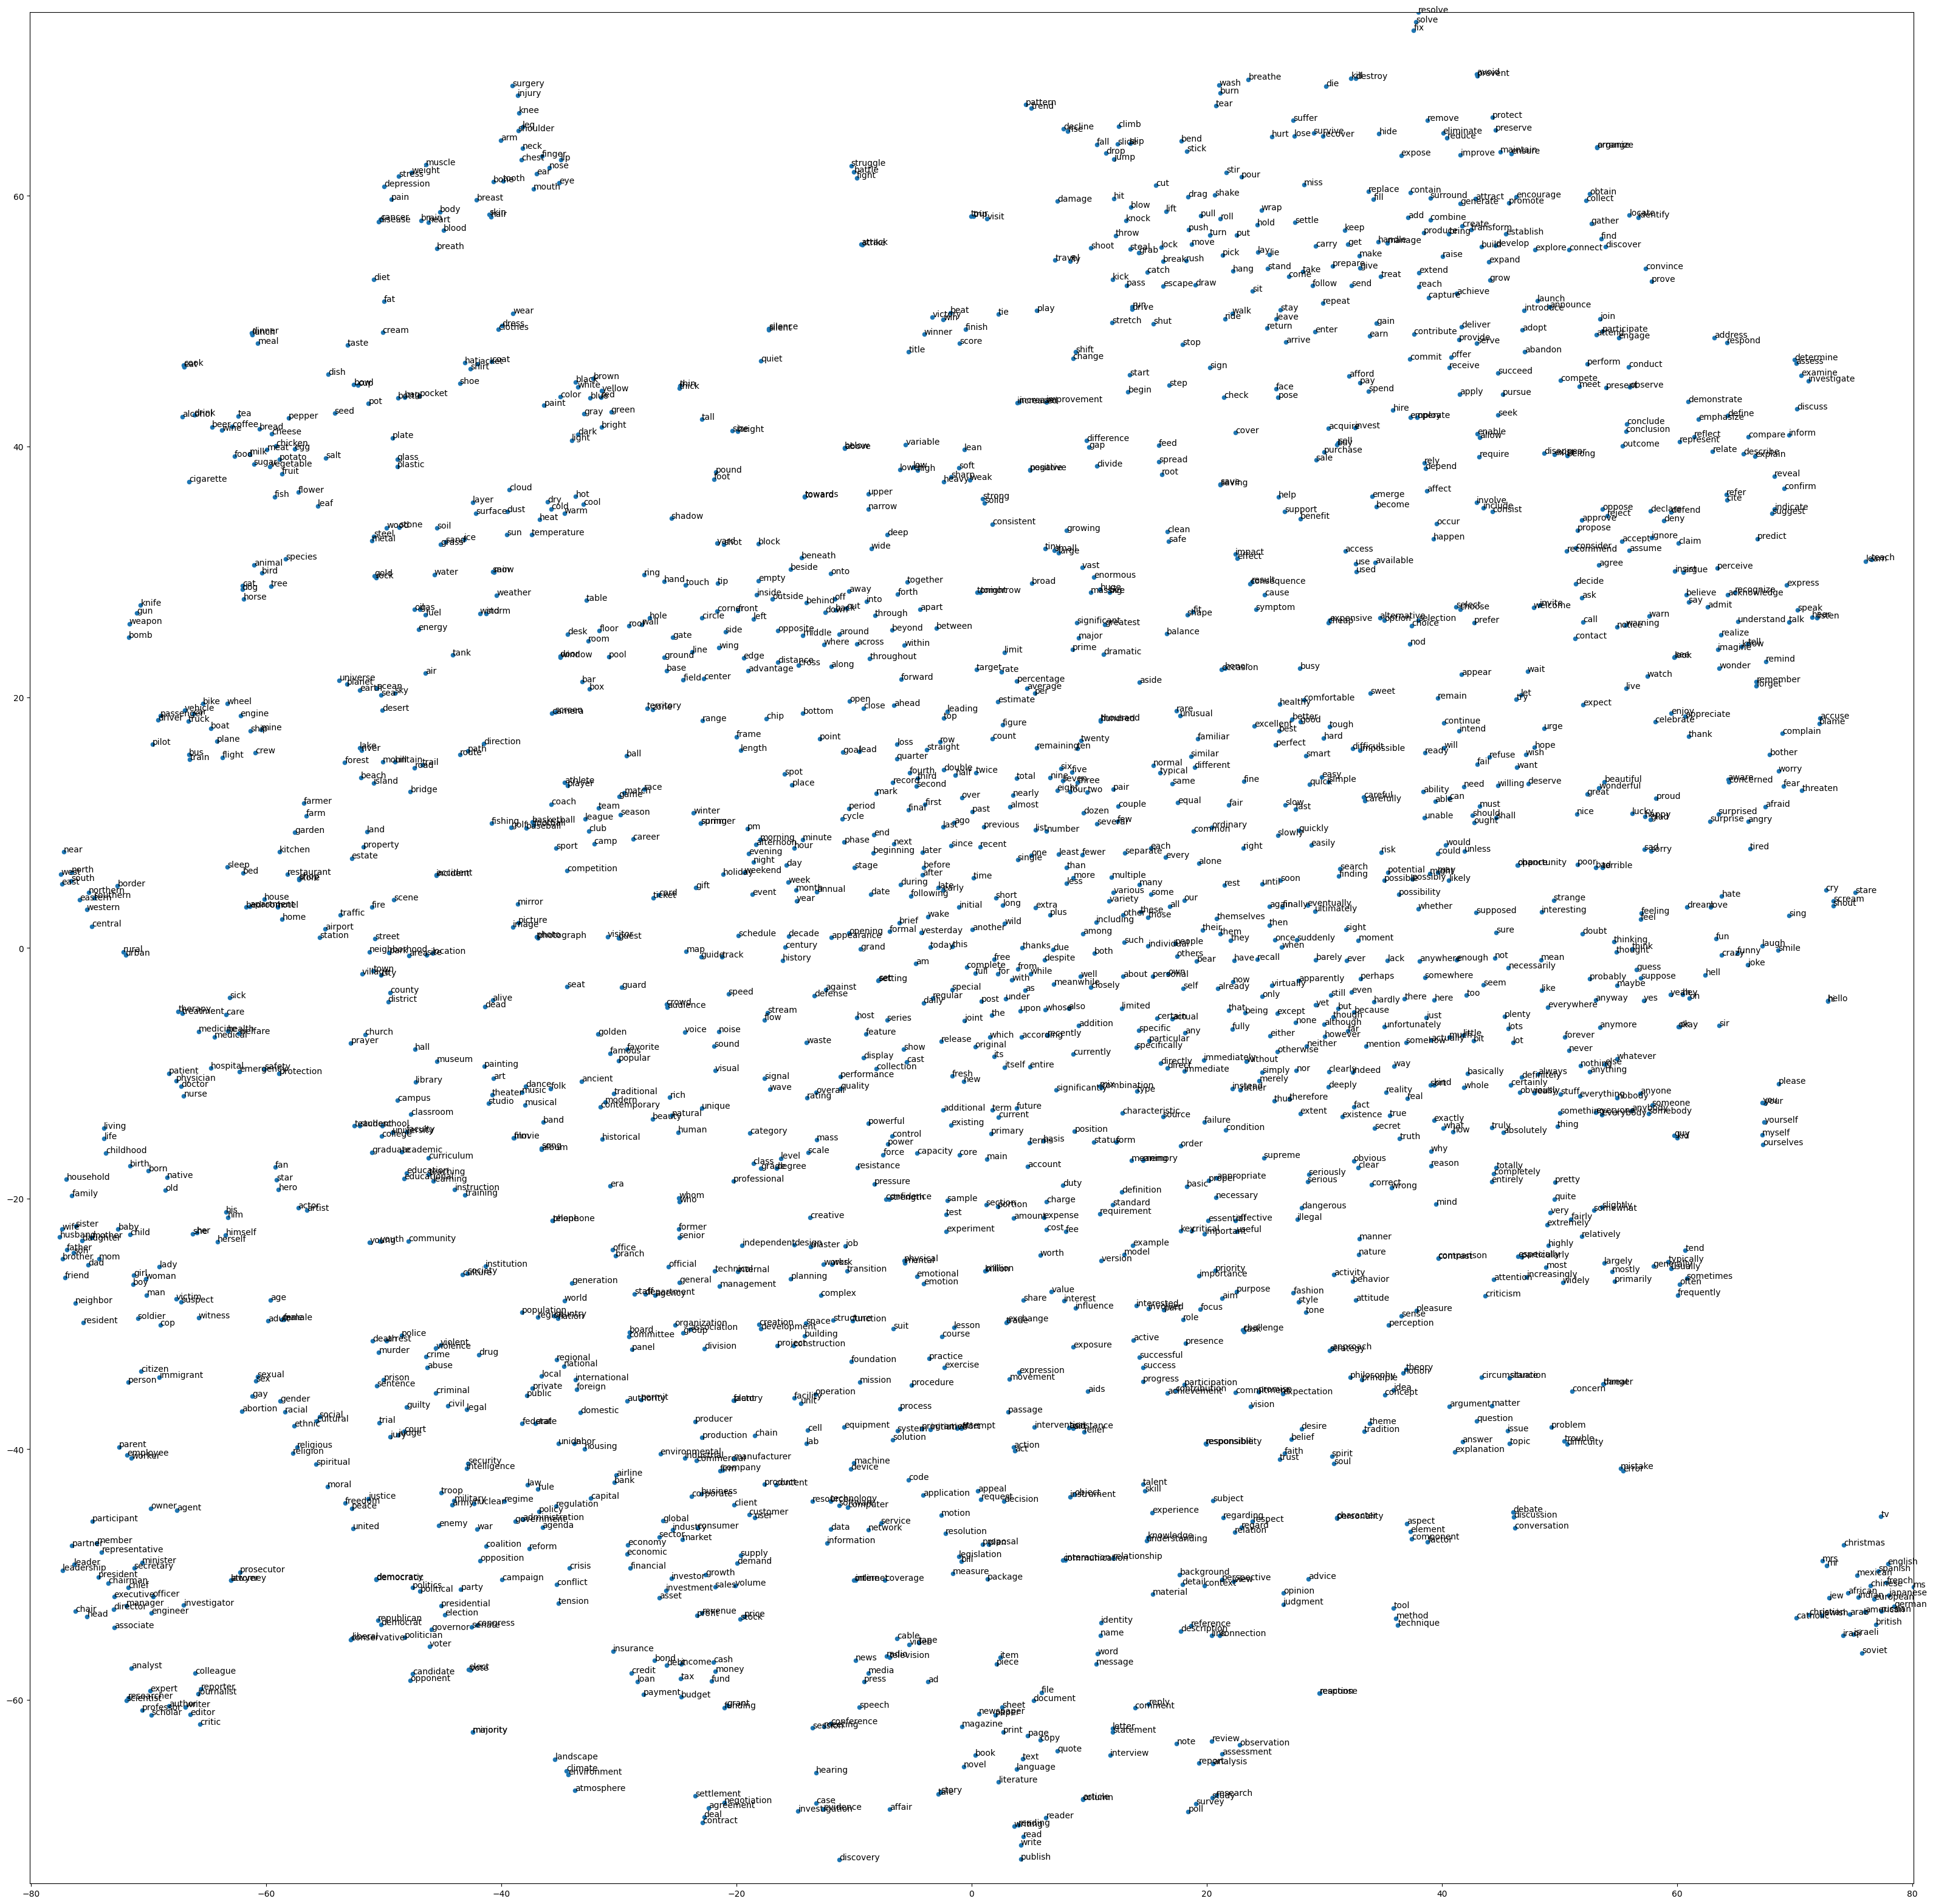

In [29]:
max_x = np.amax(reduced_matrix, axis=0)[0]
max_y = np.amax(reduced_matrix, axis=0)[1]

from nltk.corpus import stopwords

plt.figure(figsize=(40, 40), dpi=100); plt.xlim((-max_x,max_x)); plt.ylim((-max_y,max_y))
plt.scatter(reduced_matrix[:, 0], reduced_matrix[:, 1], 20);
for idx, word in enumerate(words[:]):
    x = reduced_matrix[idx, 0]
    y = reduced_matrix[idx, 1]
    plt.annotate(word, (x,y))

In [30]:
from sklearn.decomposition import PCA

def plot_data(orig_data, labels):
    pca = PCA(n_components=2)
    data = pca.fit_transform(orig_data)
    plt.figure(figsize=(7, 5), dpi=100)
    plt.plot(data[:,0], data[:,1], '.')
    for i in range(len(data)):
        plt.annotate(labels[i], xy = data[i])
    for i in range(int(len(data)/2)):
        plt.annotate("",
                xy=data[i],
                xytext=data[i+int(len(data)/2)],
                arrowprops=dict(arrowstyle="->",
                                connectionstyle="arc3")
                )

In [37]:
def analogy(worda, wordb, wordc):
    result = model.most_similar(negative=[worda], 
                                positive=[wordb, wordc])
    return result[0][0]
countries = ['USA', 'Colombia', 'Brazil', 'Venezuela', 'France', 'Spain', 'Egypt', 'China']
presidents = [analogy('Mexico', 'Tacos', country) for country in countries]
pp(zip(countries,presidents))

           0         1
0        USA   Banh_Mi
1   Colombia    Arepas
2     Brazil  Feijoada
3  Venezuela    Arepas
4     France    Crêpes
5      Spain     tapas
6      Egypt   Falafel
7      China       Wok


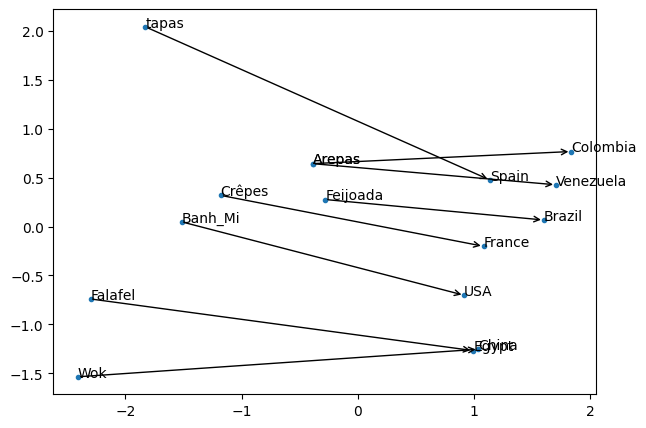

In [39]:
labels = countries + presidents
data = [model[w] for w in labels]
plot_data(data, labels)